In [15]:
from google.colab import drive

drive.mount('/content/drive')

%cd "/content/drive/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26


In [16]:
pip install -r requirements.txt

# Dataset Analysis

In [17]:
from ucimlrepo import fetch_ucirepo

try:
    dataset = fetch_ucirepo(id=891)
    # Create pandas DataFrame
    df = dataset.data.original
except ConnectionError as e:  # In case of ucimlrepo failure
    print(f"An error occurred while fetching the dataset: {e}")
    print("Trying with local CSV file...")

    import pandas as pd

    df = pd.read_csv("/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26dataset/diabetes_binary_health_indicators_BRFSS2015.csv")

In [18]:
df.dtypes

,0
ID,int64
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64


In [19]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [20]:
# Separate features and target variable
try:
    features = df.drop(columns=["ID", "Diabetes_binary"])
except Exception as e:  # In case of ucimlrepo failure
    print(f"An error occurred while dropping columns: {e}")
    features = df.drop(columns=["Diabetes_binary"])
features.dtypes

,0
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64
Veggies,int64


In [21]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64", "float64"]).columns
FEATURES_NUMBER = len(numeric_features)
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [22]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Dataset Splitting

In [24]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation
X = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# PCA

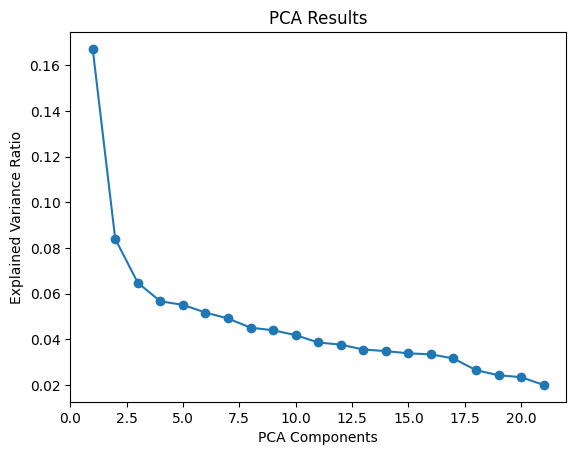

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [26]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [27]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


In [28]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


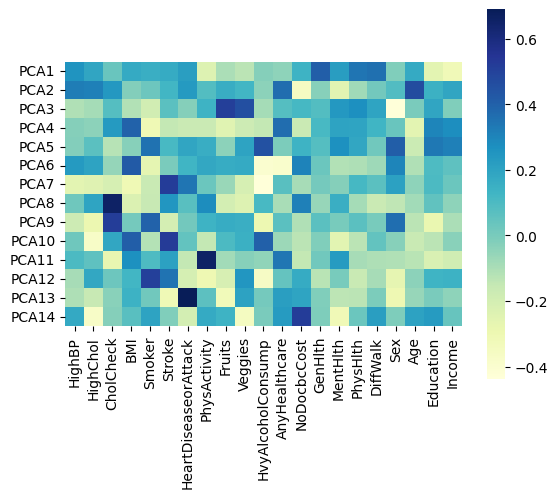

In [29]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

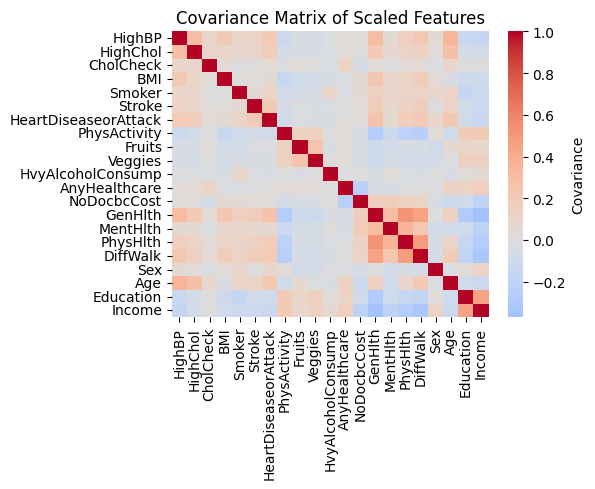

Covariance matrix shape: (21, 21)


In [30]:
import numpy as np

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

In [31]:
# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


È stato necessario selezionare parecchie componenti princiapli perchè, come si nota dalla matrice di covarianza, abbiamo in generale una bassa correlazione tra le feature.

# Neural Network

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    # Predizioni e binarizzazione
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.show()

    # Report di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcolo ROC-AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Curve di Loss e Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.show()

## No PCA

### Original Features

In [34]:
# 2. Creazione del Modello
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8532 - loss: 0.3623 - val_accuracy: 0.8654 - val_loss: 0.3192
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8618 - loss: 0.3261 - val_accuracy: 0.8661 - val_loss: 0.3175
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8650 - loss: 0.3188 - val_accuracy: 0.8651 - val_loss: 0.3167
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8647 - loss: 0.3180 - val_accuracy: 0.8637 - val_loss: 0.3175
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8661 - loss: 0.3157 - val_accuracy: 0.8657 - val_loss: 0.3168
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8654 - loss: 0.3179 - val_accuracy: 0.8650 - val_loss: 0.3160
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8665 - loss: 0.3147 - val_accuracy: 0.8645 - val_loss: 0.3161
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8634 - loss: 0.3181 - val_ac

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 747us/step


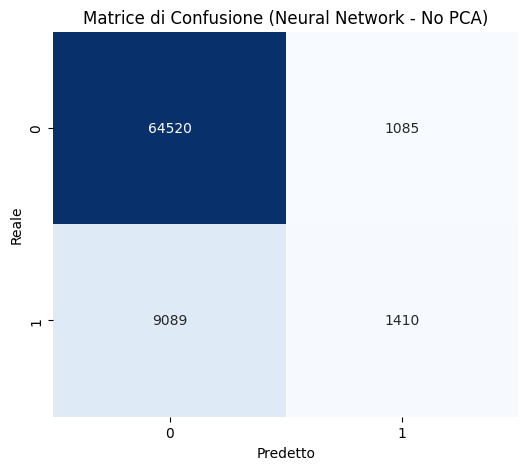

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.57      0.13      0.22     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.56      0.57     76104
weighted avg       0.83      0.87      0.83     76104



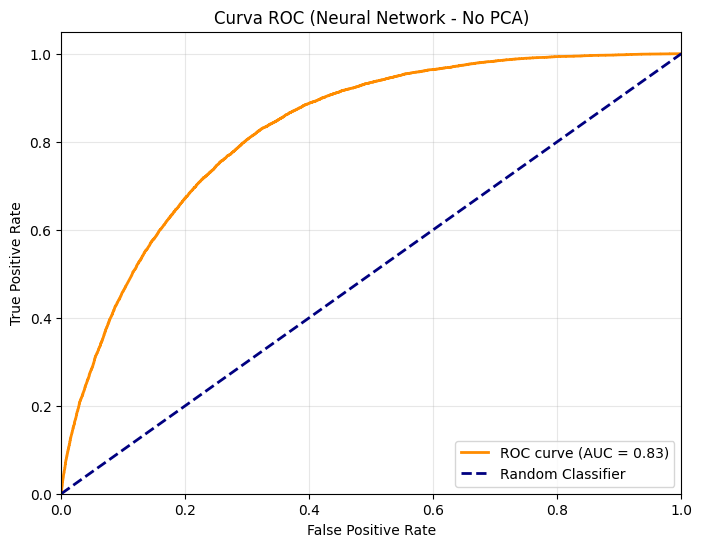


AUC Score: 0.8265


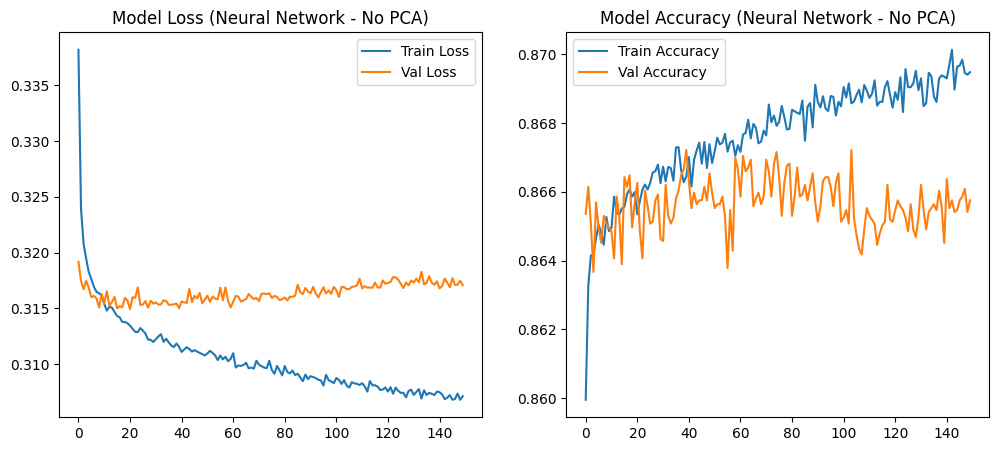

In [35]:
# 5. Valutazione
evaluate_and_plot(
    model, X_test, y_test, history, title_suffix="Neural Network - No PCA"
)

### Undersampling

Class Balancing

In [36]:
# 1. Creazione dataset bilanciato (undersampling su tutto il dataset)
idx_minority = np.where(y == 1)[0]
idx_majority = np.where(y == 0)[0]

n_minority = len(idx_minority)

idx_majority_downsampled = np.random.choice(
    idx_majority, size=n_minority, replace=False
)

idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
np.random.shuffle(idx_balanced)

X_bal = X[idx_balanced]
y_bal = y[idx_balanced]

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Train/test split sul dataset bilanciato
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


In [37]:
# 3. Creazione del Modello
model_pca_under = Sequential()
model_pca_under.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_pca_under.add(Dropout(0.5))

model_pca_under.add(Dense(32, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(16, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(1, activation="sigmoid"))

model_pca_under.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento
history_pca_under = model_pca_under.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6433 - loss: 0.6365 - val_accuracy: 0.7482 - val_loss: 0.5137
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7337 - loss: 0.5459 - val_accuracy: 0.7498 - val_loss: 0.5055
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7400 - loss: 0.5355 - val_accuracy: 0.7496 - val_loss: 0.5073
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7441 - loss: 0.5300 - val_accuracy: 0.7515 - val_loss: 0.5054
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7505 - loss: 0.5248 - val_accuracy: 0.7515 - val_loss: 0.5082
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7501 - loss: 0.5222 - val_accuracy: 0.7545 - val_loss: 0.5031
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7488 - loss: 0.5224 - val_accuracy: 0.7535 - val_loss: 0.5017
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7478 - loss: 0.5251 - val_accuracy: 0.7561

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step


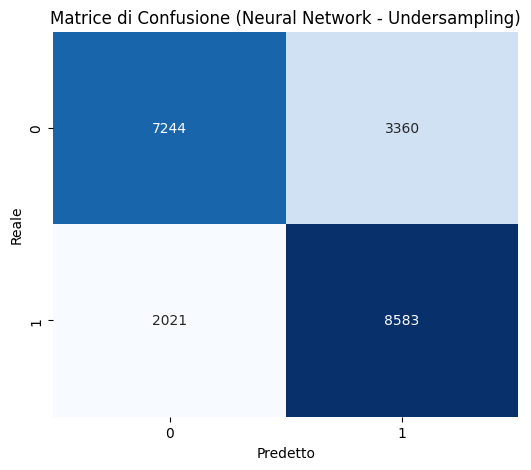

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73     10604
           1       0.72      0.81      0.76     10604

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208



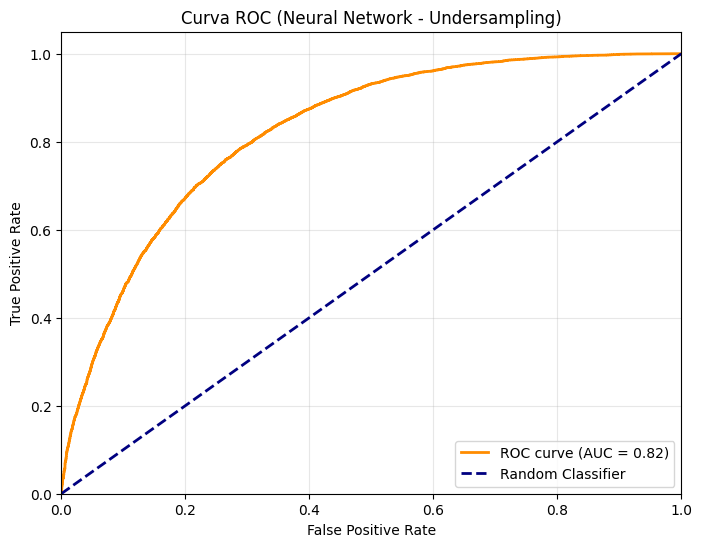


AUC Score: 0.8239


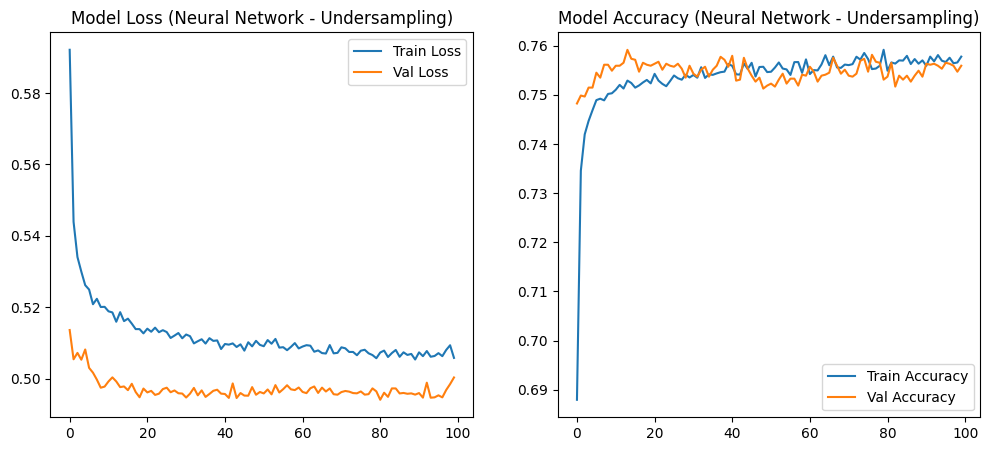

In [38]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_under,
    X_test_bal,
    y_test_bal,
    history_pca_under,
    title_suffix="Neural Network - Undersampling",
)

### Class Weights

In [39]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

model_no_pca_weighted = Sequential()

# Strati Nascosti
model_no_pca_weighted.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(64, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(32, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

model_no_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6709 - loss: 0.5639 - val_accuracy: 0.7050 - val_loss: 0.4967
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6997 - loss: 0.5239 - val_accuracy: 0.7265 - val_loss: 0.4704
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7096 - loss: 0.5185 - val_accuracy: 0.7213 - val_loss: 0.5057
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7128 - loss: 0.5106 - val_accuracy: 0.7206 - val_loss: 0.5116
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7185 - loss: 0.5103 - val_accuracy: 0.7202 - val_loss: 0.5150
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7166 - loss: 0.5082 - val_accuracy: 0.7152 - val_loss: 0.5175
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7131 - loss: 0.5085 - val_accuracy: 0.7445 - val_loss: 0.4729
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7224 - loss: 0.5105 - val_accuracy: 0.7213

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 781us/step


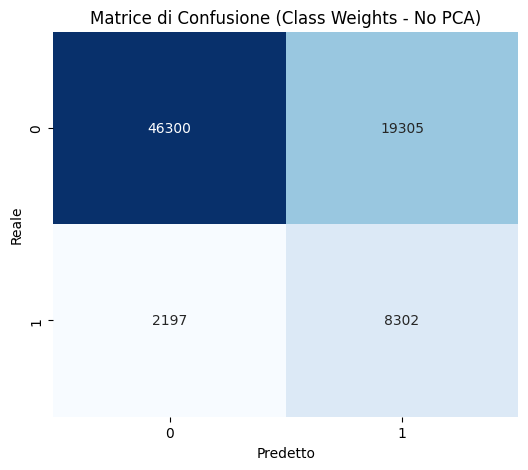

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     65605
           1       0.30      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.86      0.72      0.76     76104



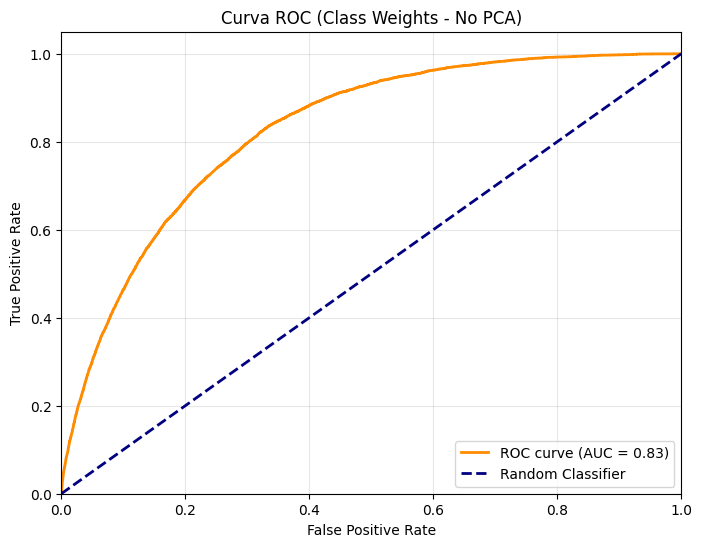


AUC Score: 0.8252


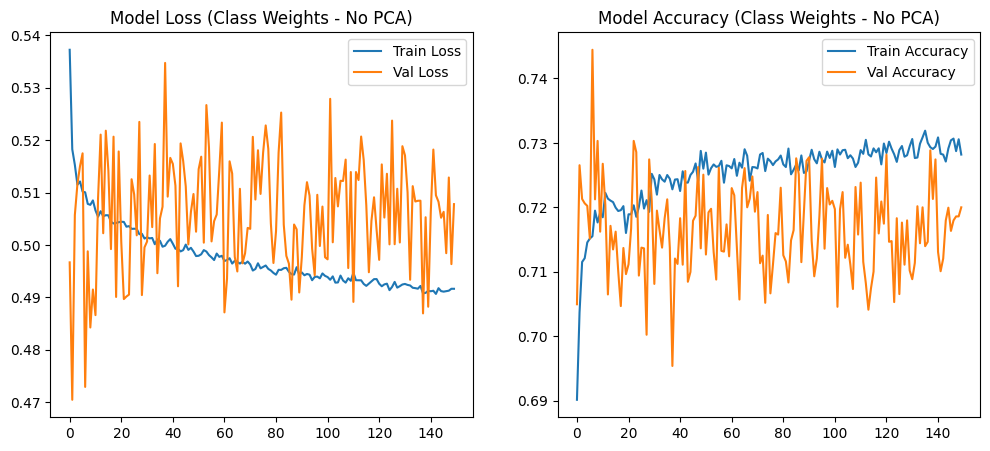

In [40]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_weighted,
    X_test,
    y_test,
    history_no_pca_weighted,
    title_suffix="Class Weights - No PCA",
)

### Focal Loss
Va leggermente meglio (non so quanto, da analizzare...) però ha un maggior onere computazionale.
A livello di tempi Class Weights è molto più veloce.

In [41]:
# Definizione corretta della Focal Loss per classificazione binaria
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss per classificazione binaria sbilanciata.

    Parameters:
    - gamma: focusing parameter (default=2.0). Maggiore è gamma, più il modello si concentra sugli esempi difficili
    - alpha: peso per la classe positiva (default=0.25). Per dati sbilanciati, usa alpha ≈ frequenza classe negativa
    """

    def focal_loss_fixed(y_true, y_pred):
        # Converti tutto a float32 per evitare problemi di tipo
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Binary Cross Entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        # Focal Loss modulation
        # Per gli esempi della classe 1 (y_true=1): p_t = y_pred
        # Per gli esempi della classe 0 (y_true=0): p_t = 1 - y_pred
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)

        # Alpha balancing (converti alpha a float32)
        alpha_f32 = tf.constant(alpha, dtype=tf.float32)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha_f32, 1 - alpha_f32)

        # Focal term: (1 - p_t)^gamma (converti gamma a float32)
        gamma_f32 = tf.constant(gamma, dtype=tf.float32)
        focal_weight = tf.pow(1.0 - p_t, gamma_f32)

        # Focal Loss finale
        focal_loss = alpha_t * focal_weight * bce

        return tf.reduce_mean(focal_loss)

    return focal_loss_fixed

In [42]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
class_freq_np = np.bincount(y_train.astype(int))
alpha_optimal_np = float(class_freq_np[0] / (class_freq_np[0] + class_freq_np[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal_np:.3f}")

# 2. Creazione del Modello
model_no_pca_focal = Sequential()

# Strati Nascosti
model_no_pca_focal.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(64, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(32, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
model_no_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal_np),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_no_pca_focal = model_no_pca_focal.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6775 - loss: 0.0363 - val_accuracy: 0.6674 - val_loss: 0.0322
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6900 - loss: 0.0325 - val_accuracy: 0.7125 - val_loss: 0.0317
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7025 - loss: 0.0321 - val_accuracy: 0.7175 - val_loss: 0.0315
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7075 - loss: 0.0318 - val_accuracy: 0.7292 - val_loss: 0.0316
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7098 - loss: 0.0317 - val_accuracy: 0.7123 - val_loss: 0.0315
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7137 - loss: 0.0316 - val_accuracy: 0.7010 - val_loss: 0.0315
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7111 - loss: 0.0317 - val_accuracy: 0.7236 - val_loss: 0.0314
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7221 - loss: 0.0314 - val_accuracy: 0.7329

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 697us/step


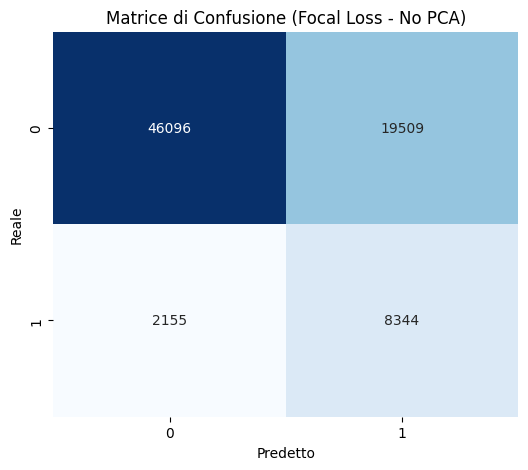

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.86      0.72      0.76     76104



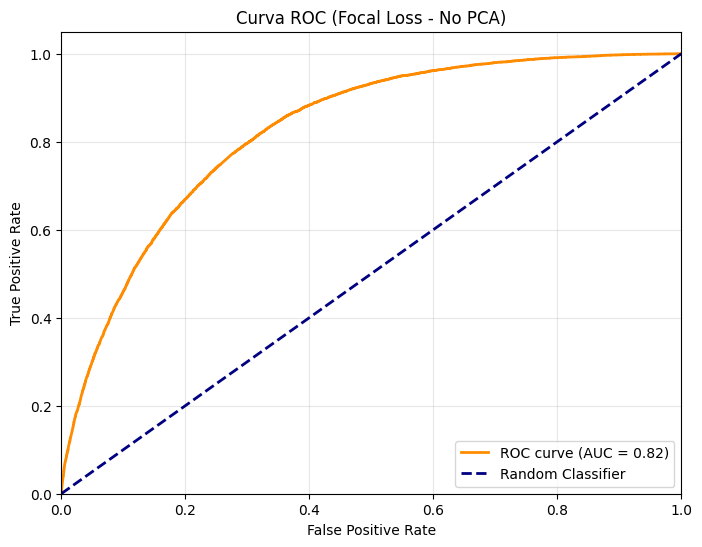


AUC Score: 0.8248


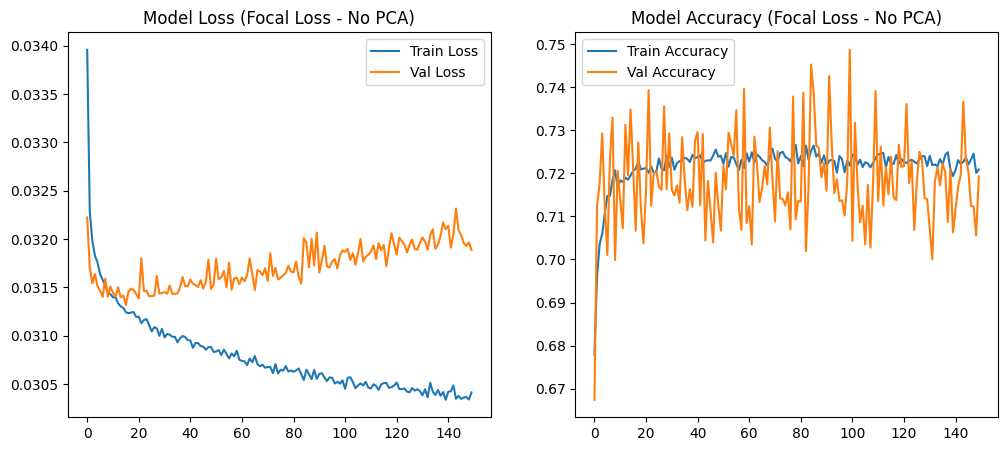

In [43]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_focal,
    X_test,
    y_test,
    history_no_pca_focal,
    title_suffix="Focal Loss - No PCA",
)

## PCA

### Class Weights

In [44]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5936 - loss: 0.6436 - val_accuracy: 0.6675 - val_loss: 0.5224
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6686 - loss: 0.5556 - val_accuracy: 0.6751 - val_loss: 0.5205
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6740 - loss: 0.5484 - val_accuracy: 0.6886 - val_loss: 0.5253
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6811 - loss: 0.5422 - val_accuracy: 0.7085 - val_loss: 0.5046
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6906 - loss: 0.5348 - val_accuracy: 0.7120 - val_loss: 0.5140
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6914 - loss: 0.5359 - val_accuracy: 0.7179 - val_loss: 0.5139
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6995 - loss: 0.5313 - val_accuracy: 0.7148 - val_loss: 0.5132
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6932 - loss: 0.5372 - val_accu

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 774us/step


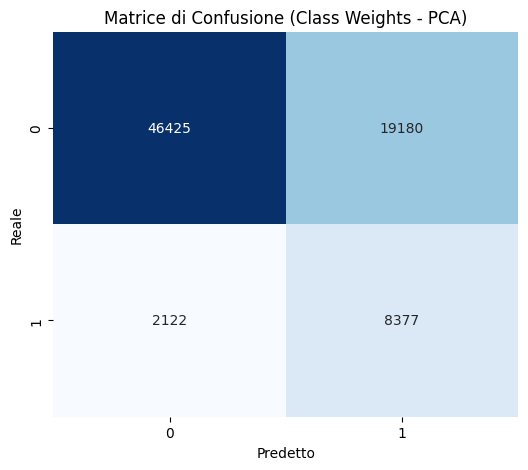

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     65605
           1       0.30      0.80      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



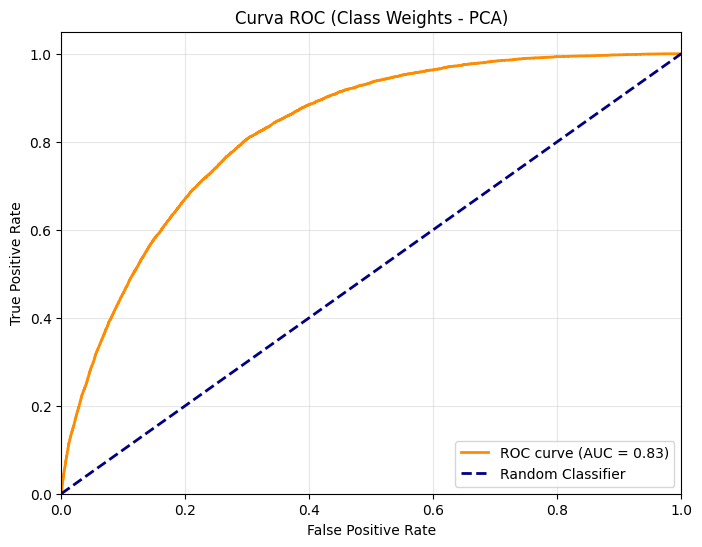


AUC Score: 0.8258


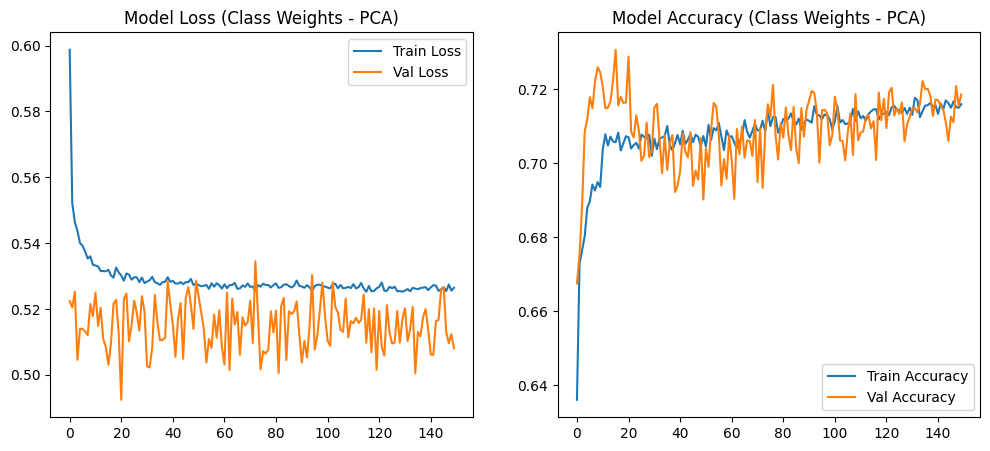

In [45]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="Class Weights - PCA",
)

### Focal Loss
Direi di togliere questa parte, non porta miglioramenti significativi.

In [46]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
# alpha ≈ freq(classe 0) per dare più peso alla classe minoritaria (1)
class_freq = np.bincount(y_train_pca.astype(int))
alpha_optimal = float(class_freq[0] / (class_freq[0] + class_freq[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal:.3f}")

# 2. Creazione del Modello
model_pca_focal = Sequential()

model_pca_focal.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(16, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(8, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
# Usa gamma=2.0 e alpha calcolato automaticamente
model_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_pca_focal = model_pca_focal.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6897 - loss: 0.0412 - val_accuracy: 0.6763 - val_loss: 0.0331
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6451 - loss: 0.0347 - val_accuracy: 0.7069 - val_loss: 0.0331
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6683 - loss: 0.0341 - val_accuracy: 0.7161 - val_loss: 0.0325
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6745 - loss: 0.0339 - val_accuracy: 0.7163 - val_loss: 0.0324
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6862 - loss: 0.0336 - val_accuracy: 0.7196 - val_loss: 0.0325
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6891 - loss: 0.0334 - val_accuracy: 0.7204 - val_loss: 0.0323
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6918 - loss: 0.0334 - val_accuracy: 0.6995 - val_loss: 0.0324
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6947 - loss: 0.0334 - val_accuracy: 0.7137

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step


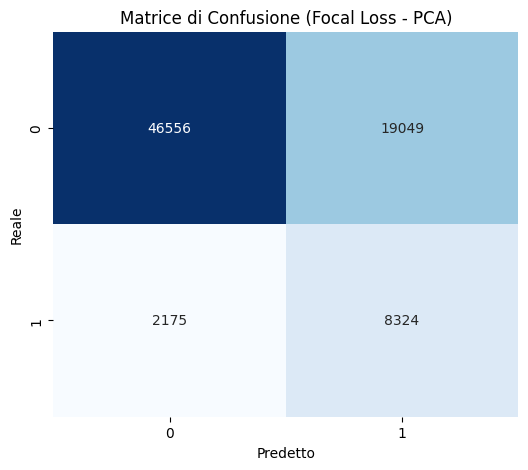

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     65605
           1       0.30      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



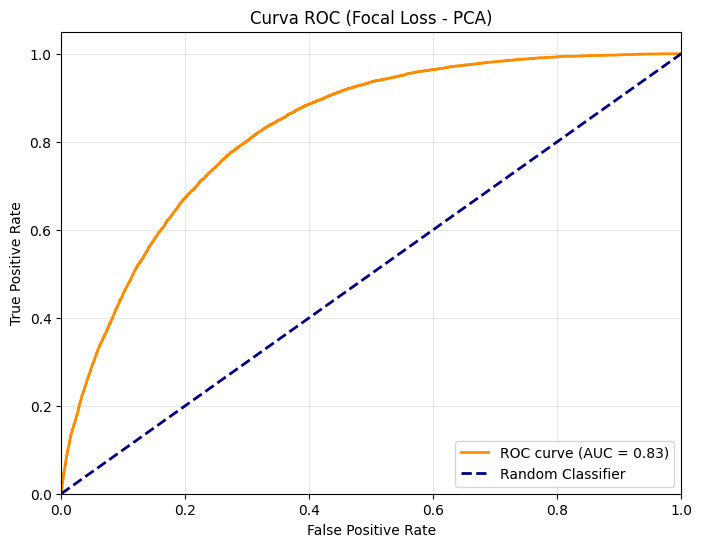


AUC Score: 0.8256


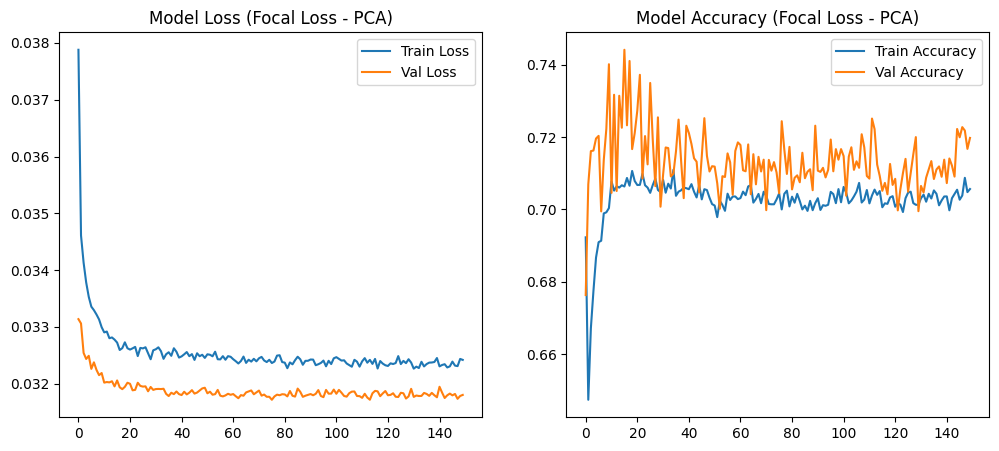

In [47]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_focal,
    X_test_pca,
    y_test_pca,
    history_pca_focal,
    title_suffix="Focal Loss - PCA",
)

# Decision Tree

In [48]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree


def show_tree_metrics(tree, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Profondità albero: {tree.get_depth()}")
    print(f"Numero di foglie: {tree.get_n_leaves()}")

    print("\n" + classification_report(y_test, y_pred))

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione"
    plt.title(title)
    plt.show()


def print_tree(tree, max_depth, title):
    plt.figure(figsize=(25, 12))
    plot_tree(
        tree,
        filled=True,
        feature_names=numeric_features,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## No PCA

### No Pruning

Accuracy: 0.7980
Profondità albero: 38
Numero di foglie: 32829

              precision    recall  f1-score   support

           0       0.89      0.87      0.88     65605
           1       0.29      0.33      0.31     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.60     76104
weighted avg       0.81      0.80      0.80     76104



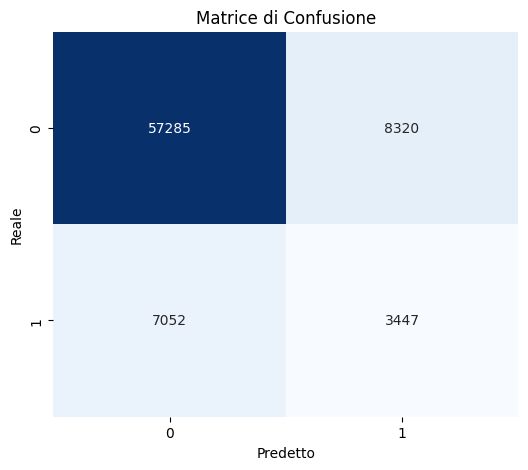

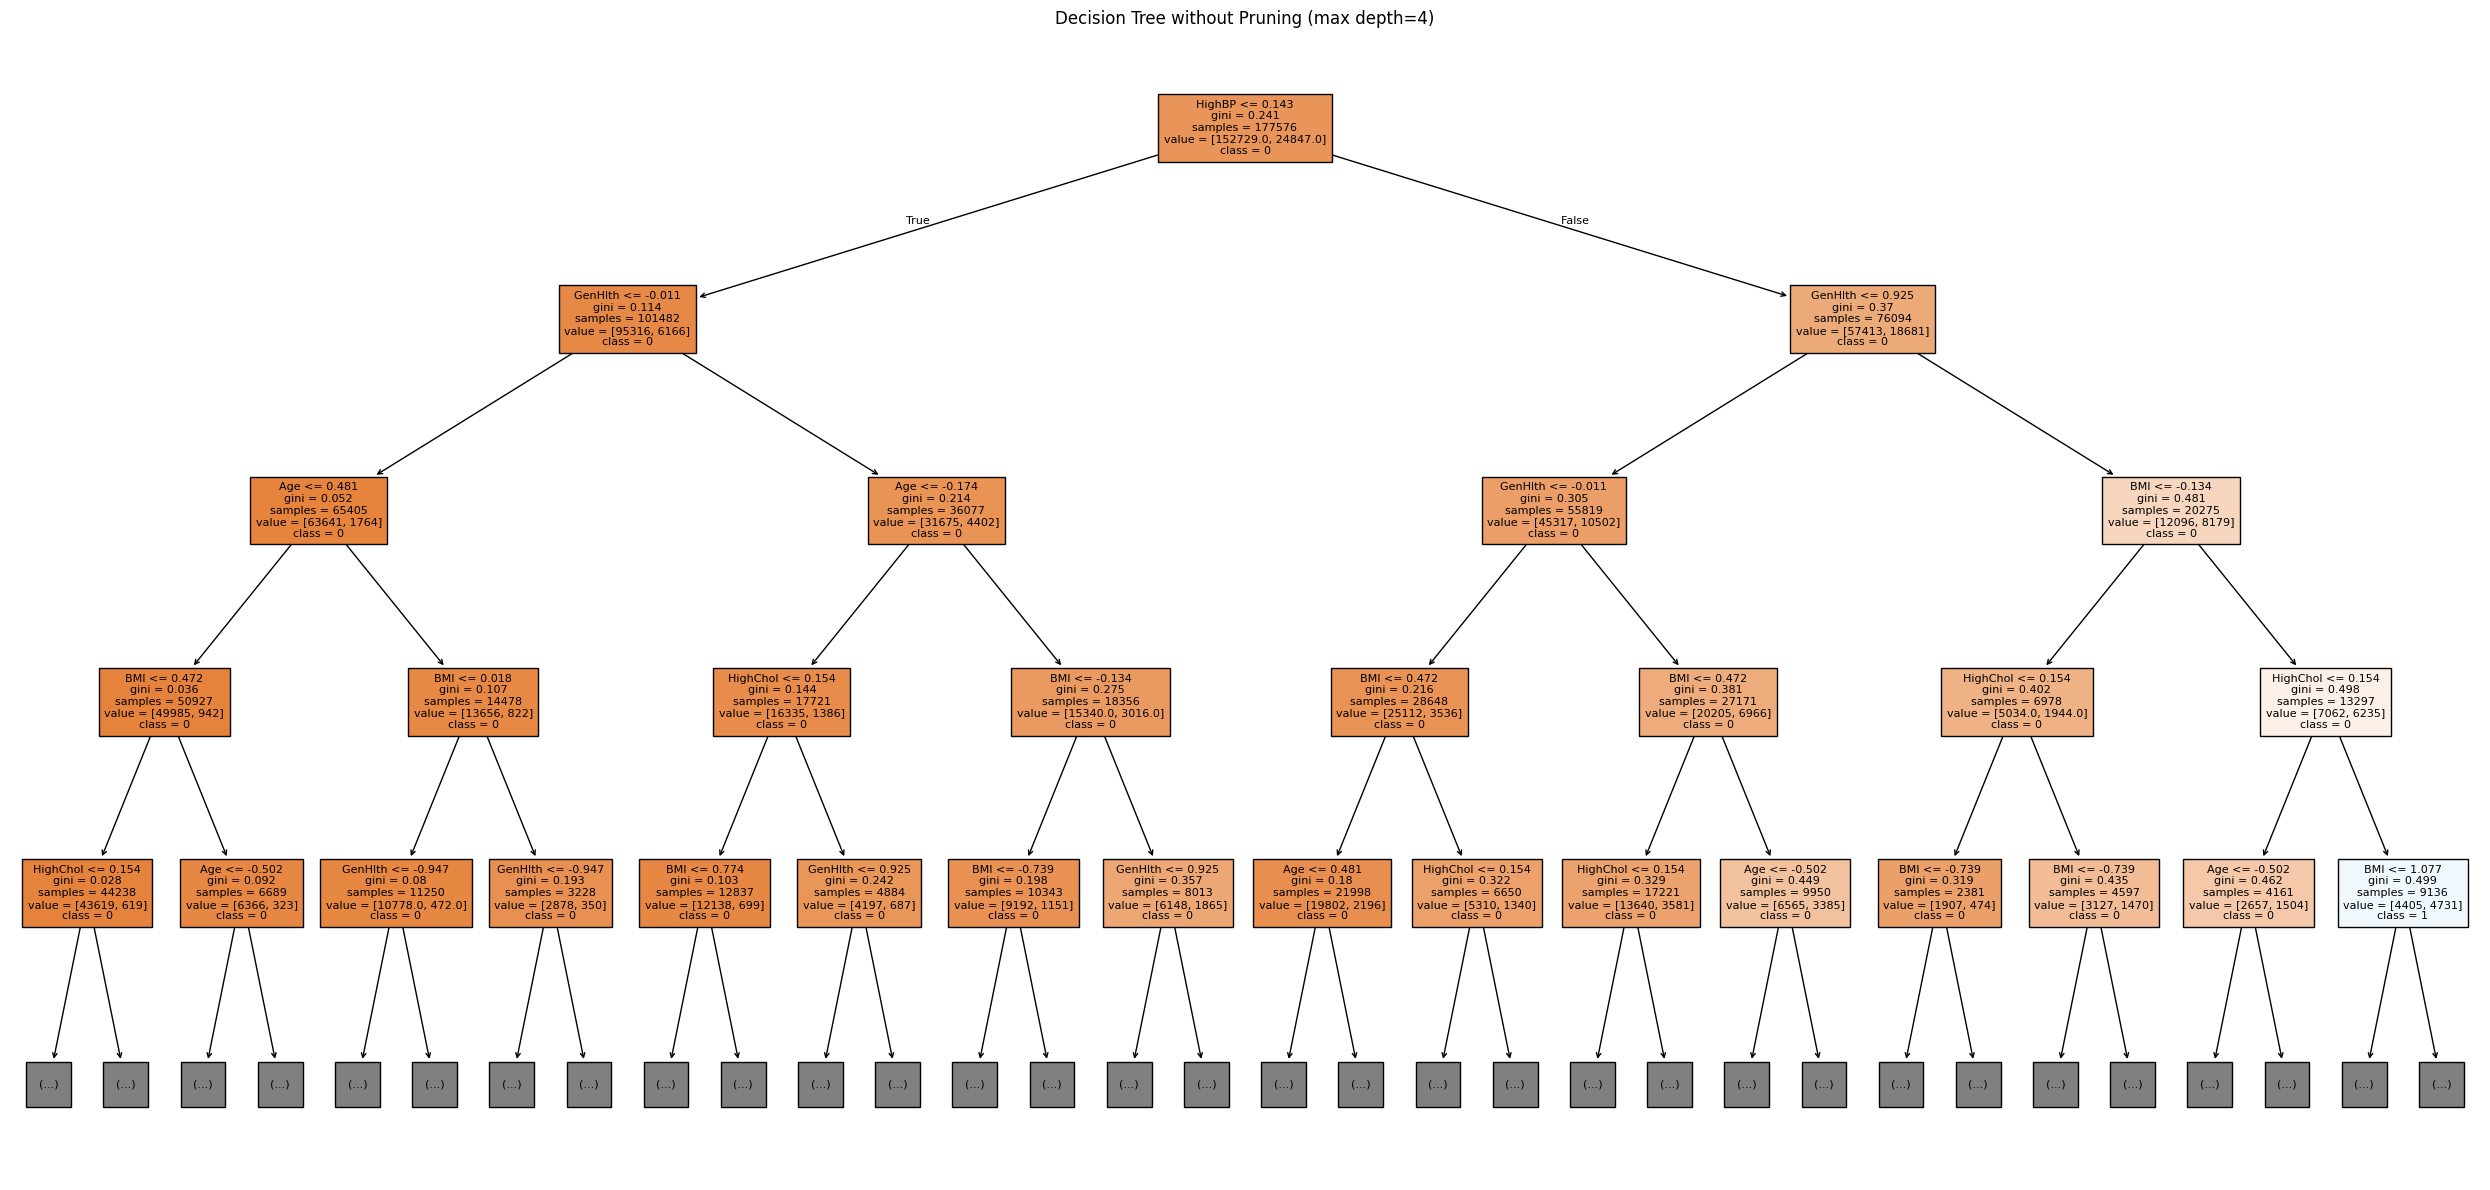

In [49]:
from sklearn.tree import DecisionTreeClassifier

dt_no_pruning = DecisionTreeClassifier(random_state=42)
dt_no_pruning.fit(X_train, y_train)

y_pred_no_prune = dt_no_pruning.predict(X_test)

show_tree_metrics(dt_no_pruning, y_test, y_pred_no_prune)
print_tree(dt_no_pruning, 4, "Decision Tree without Pruning (max depth=4)")

### With Pruning

Accuracy: 0.8654
Profondità albero: 8
Numero di foglie: 33

              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.56      0.12      0.19     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.55      0.56     76104
weighted avg       0.83      0.87      0.83     76104



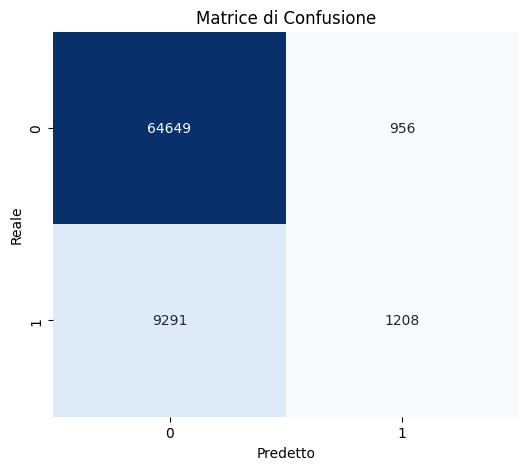

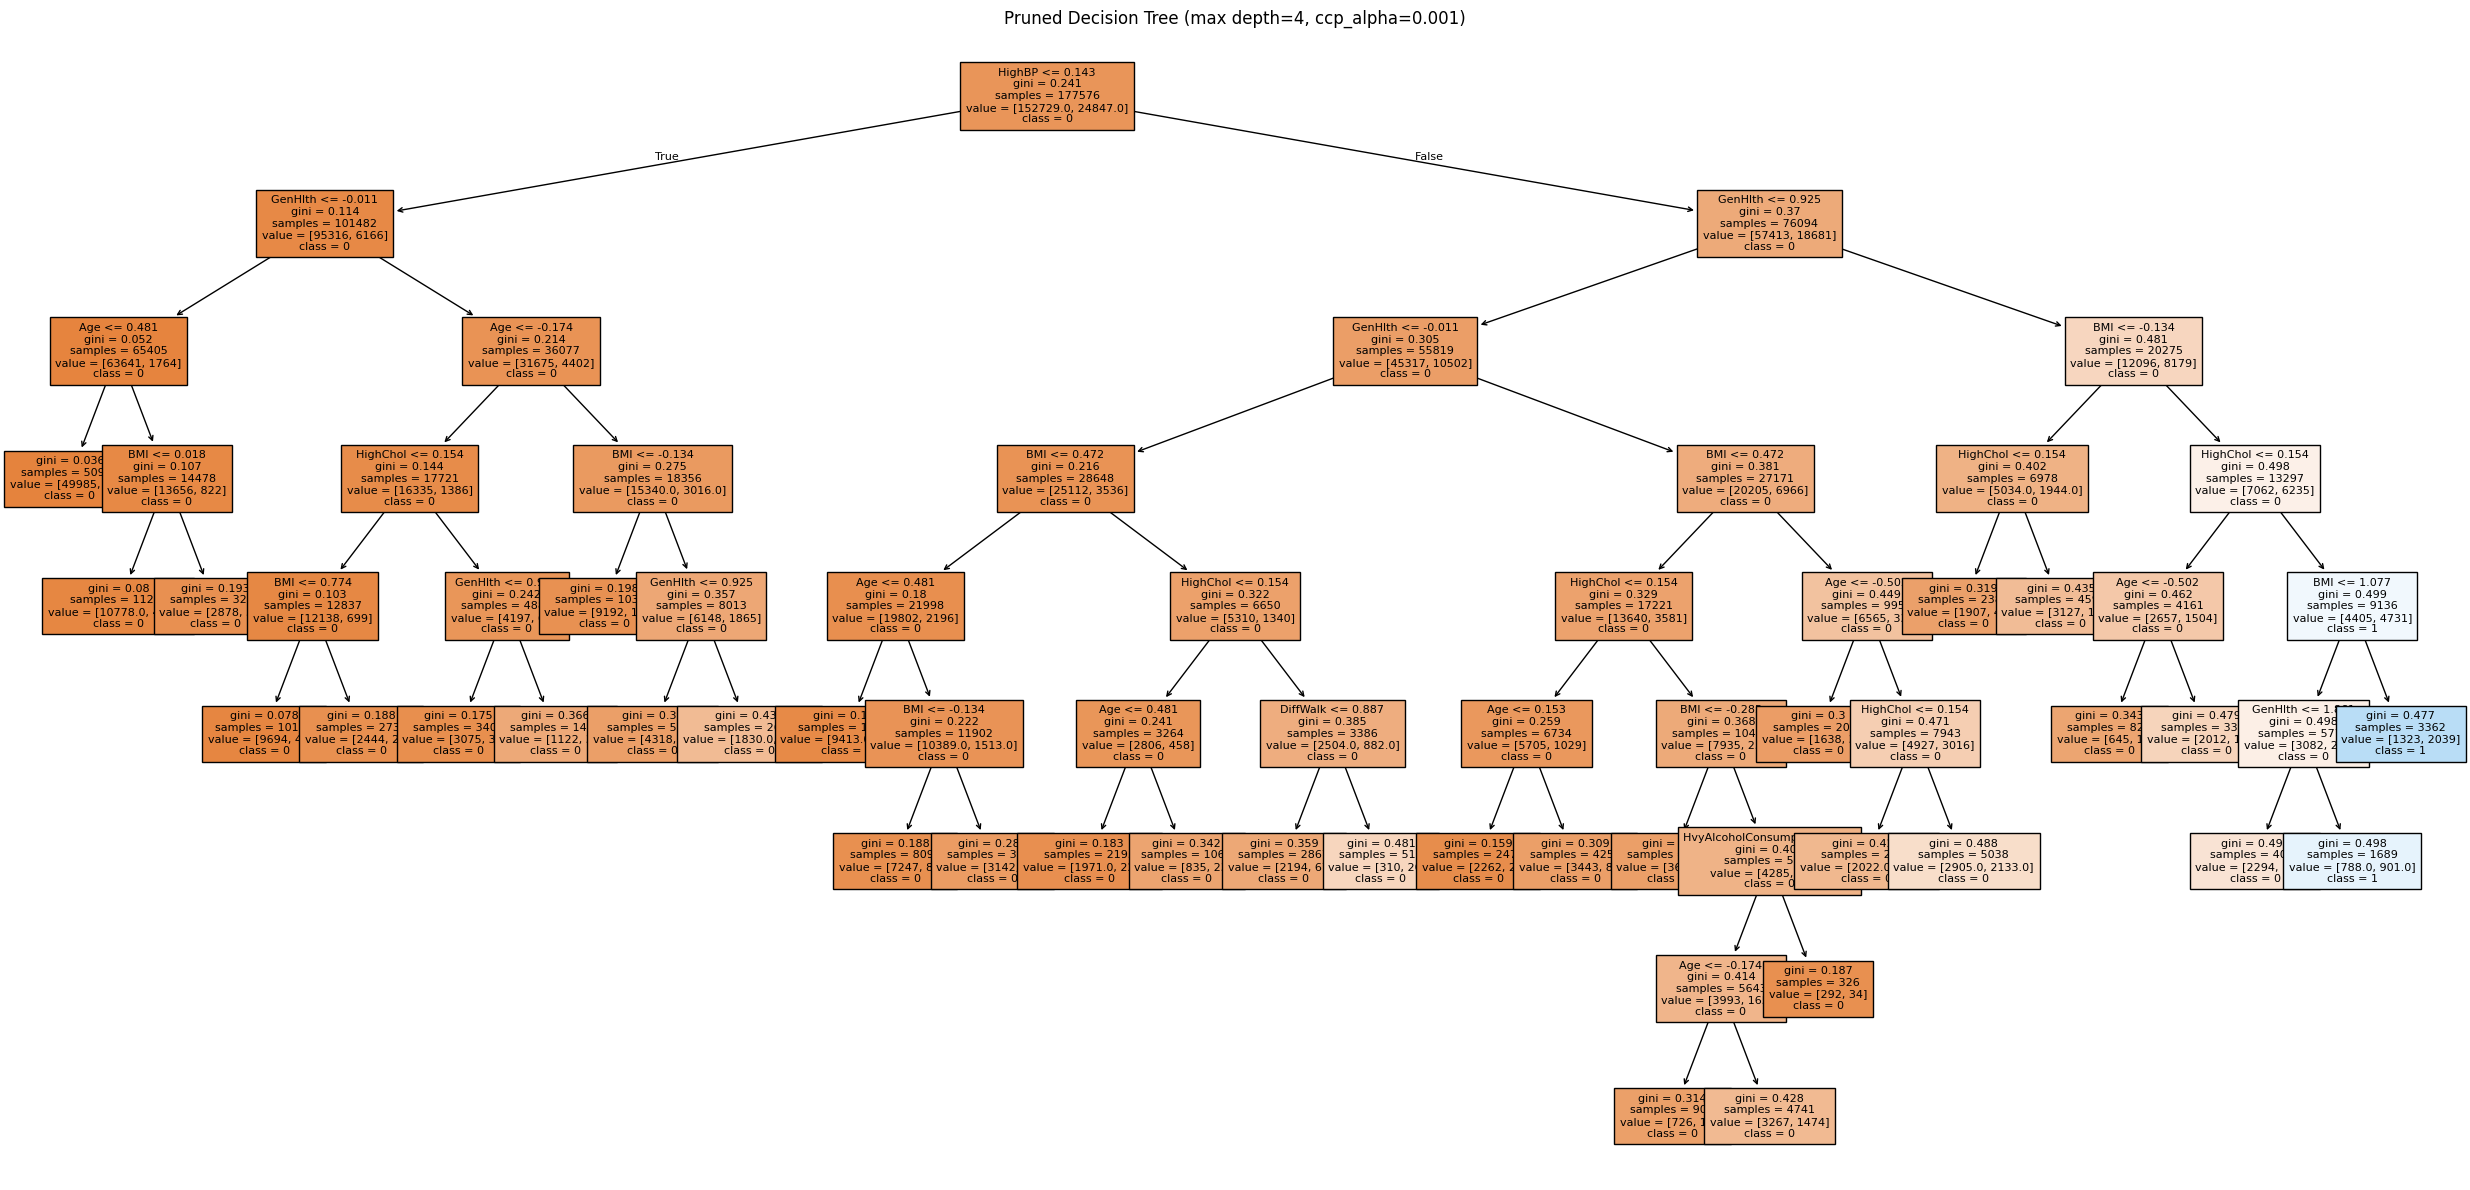

In [53]:
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
show_tree_metrics(dt_pruned, y_test, y_pred_pruned)
print_tree(dt_pruned, dt_pruned.get_depth(), "Pruned Decision Tree (max depth=4, ccp_alpha=0.001)")

## PCA

### No Pruning

Accuracy: 0.8008
Profondità albero: 50
Numero di foglie: 19037

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     65605
           1       0.29      0.31      0.30     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.59     76104
weighted avg       0.81      0.80      0.80     76104



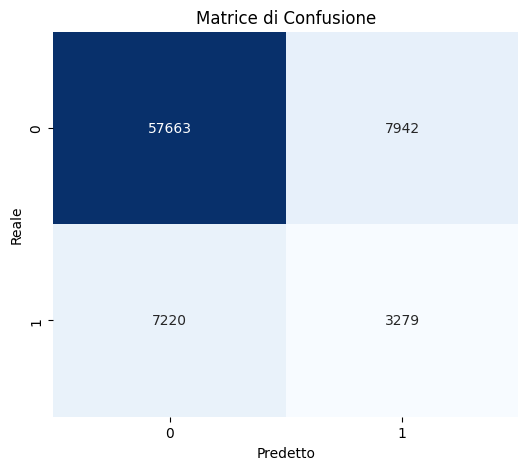

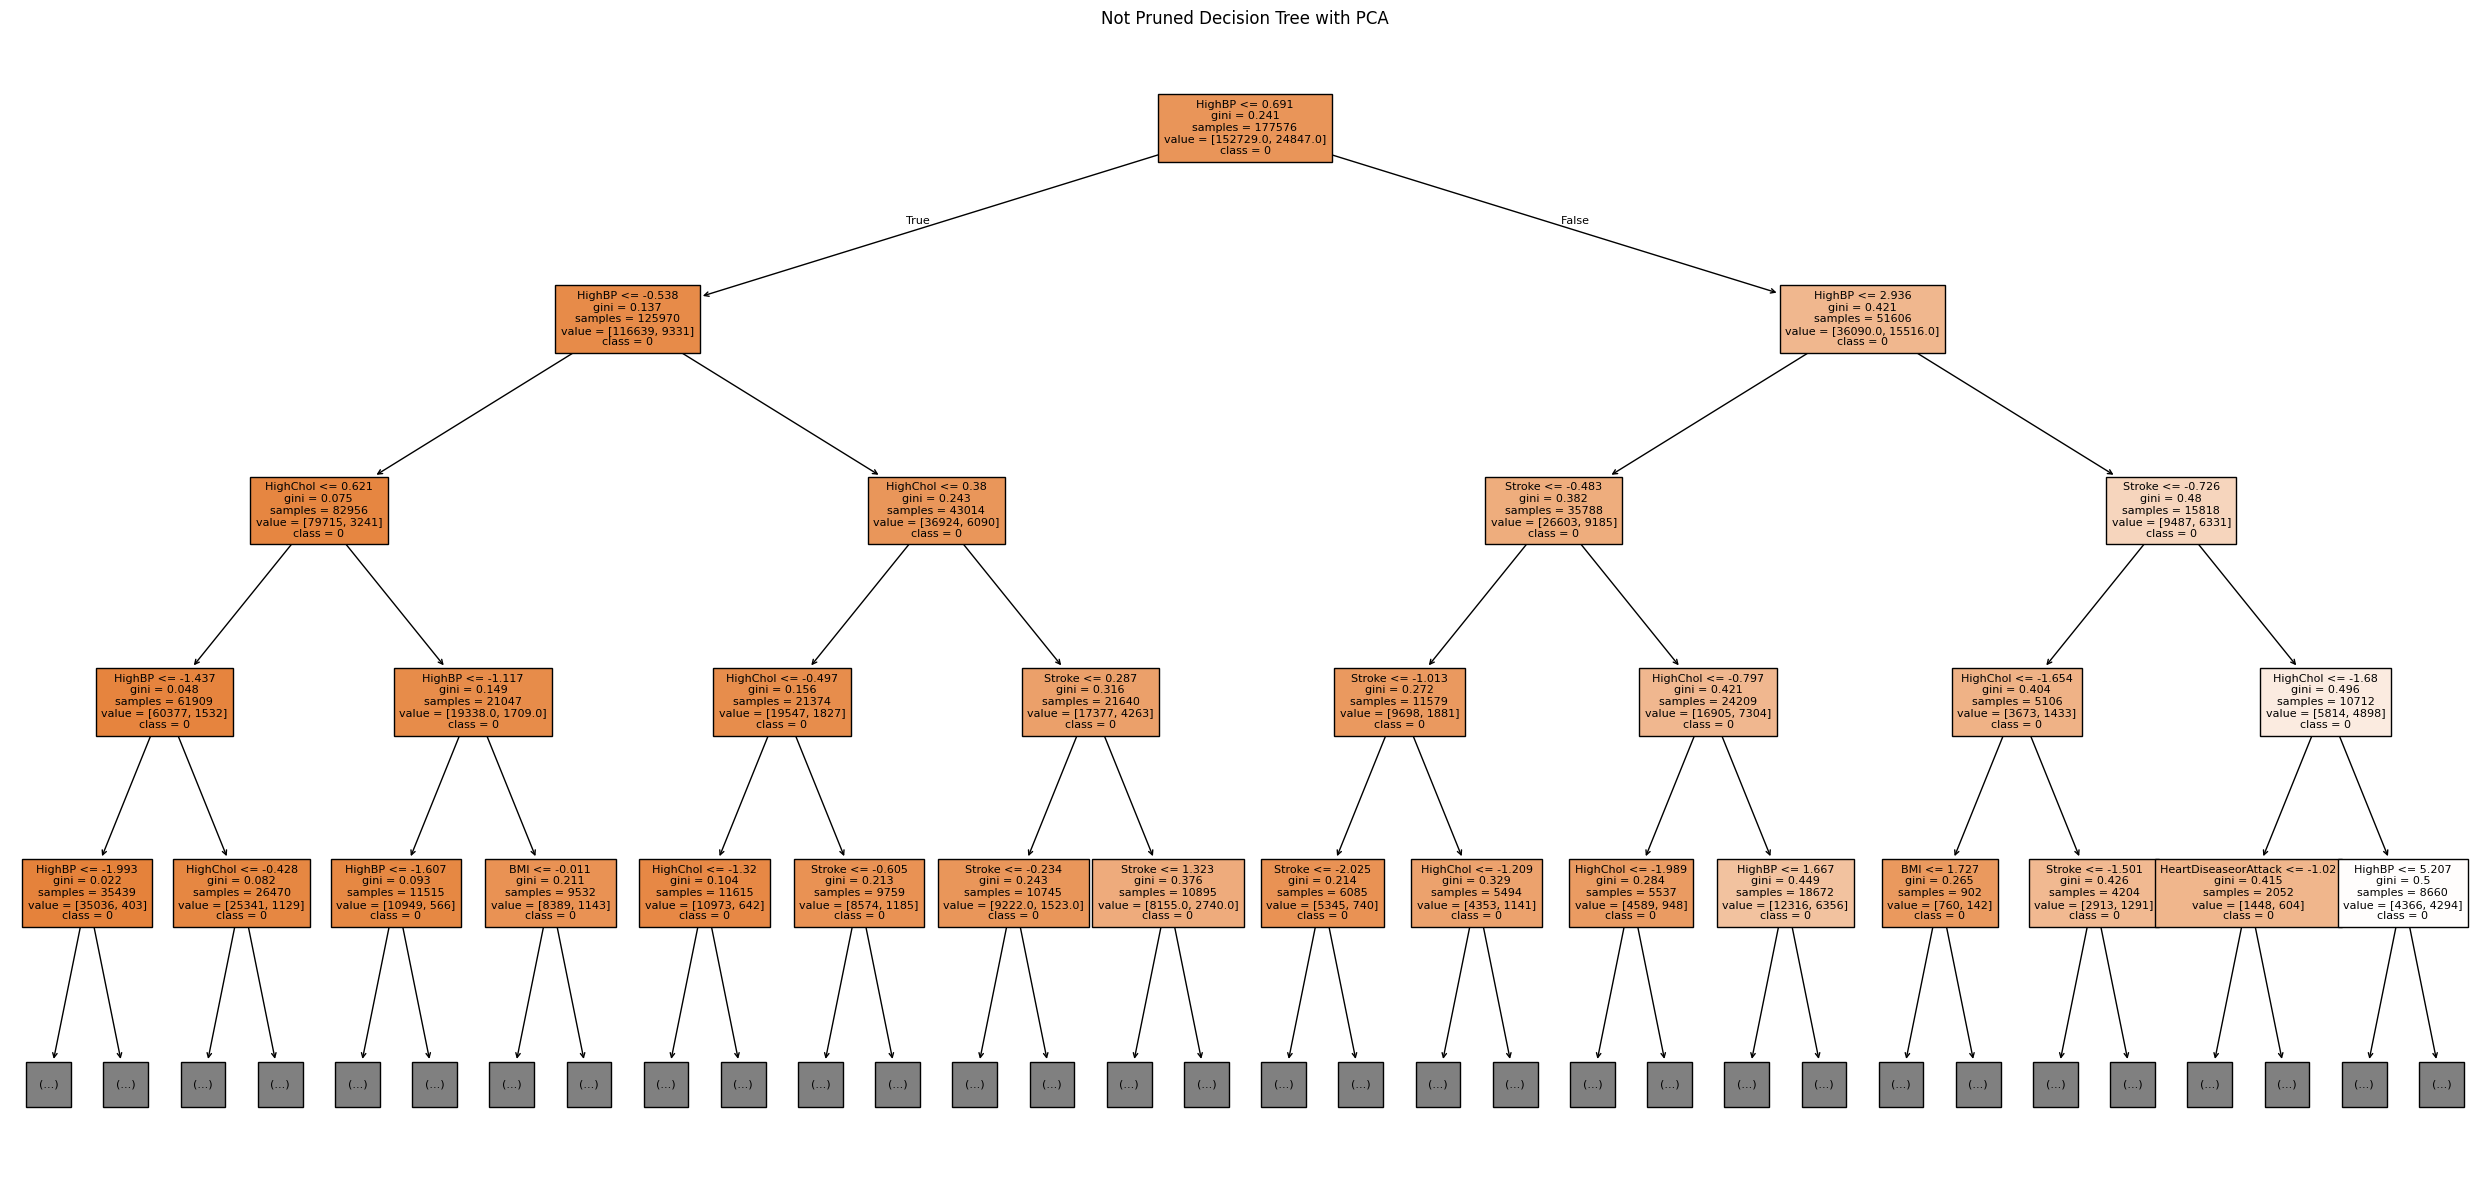

In [52]:
dt_pca_no_pruned = DecisionTreeClassifier(random_state=42)
dt_pca_no_pruned.fit(X_train_pca, y_train_pca)

y_pred_no_pruned = dt_pca_no_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_no_pruned, y_test_pca, y_pred_no_pruned)
print_tree(dt_pca_no_pruned, 4, "Not Pruned Decision Tree with PCA")

### With Pruning

Accuracy: 0.8629
Profondità albero: 7
Numero di foglie: 36

              precision    recall  f1-score   support

           0       0.87      0.98      0.93     65605
           1       0.51      0.11      0.18     10499

    accuracy                           0.86     76104
   macro avg       0.69      0.55      0.55     76104
weighted avg       0.82      0.86      0.82     76104



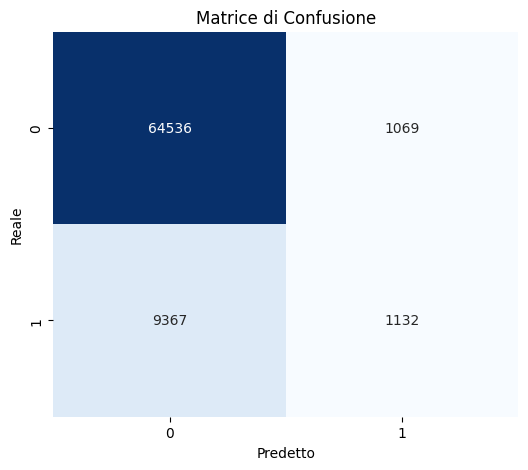

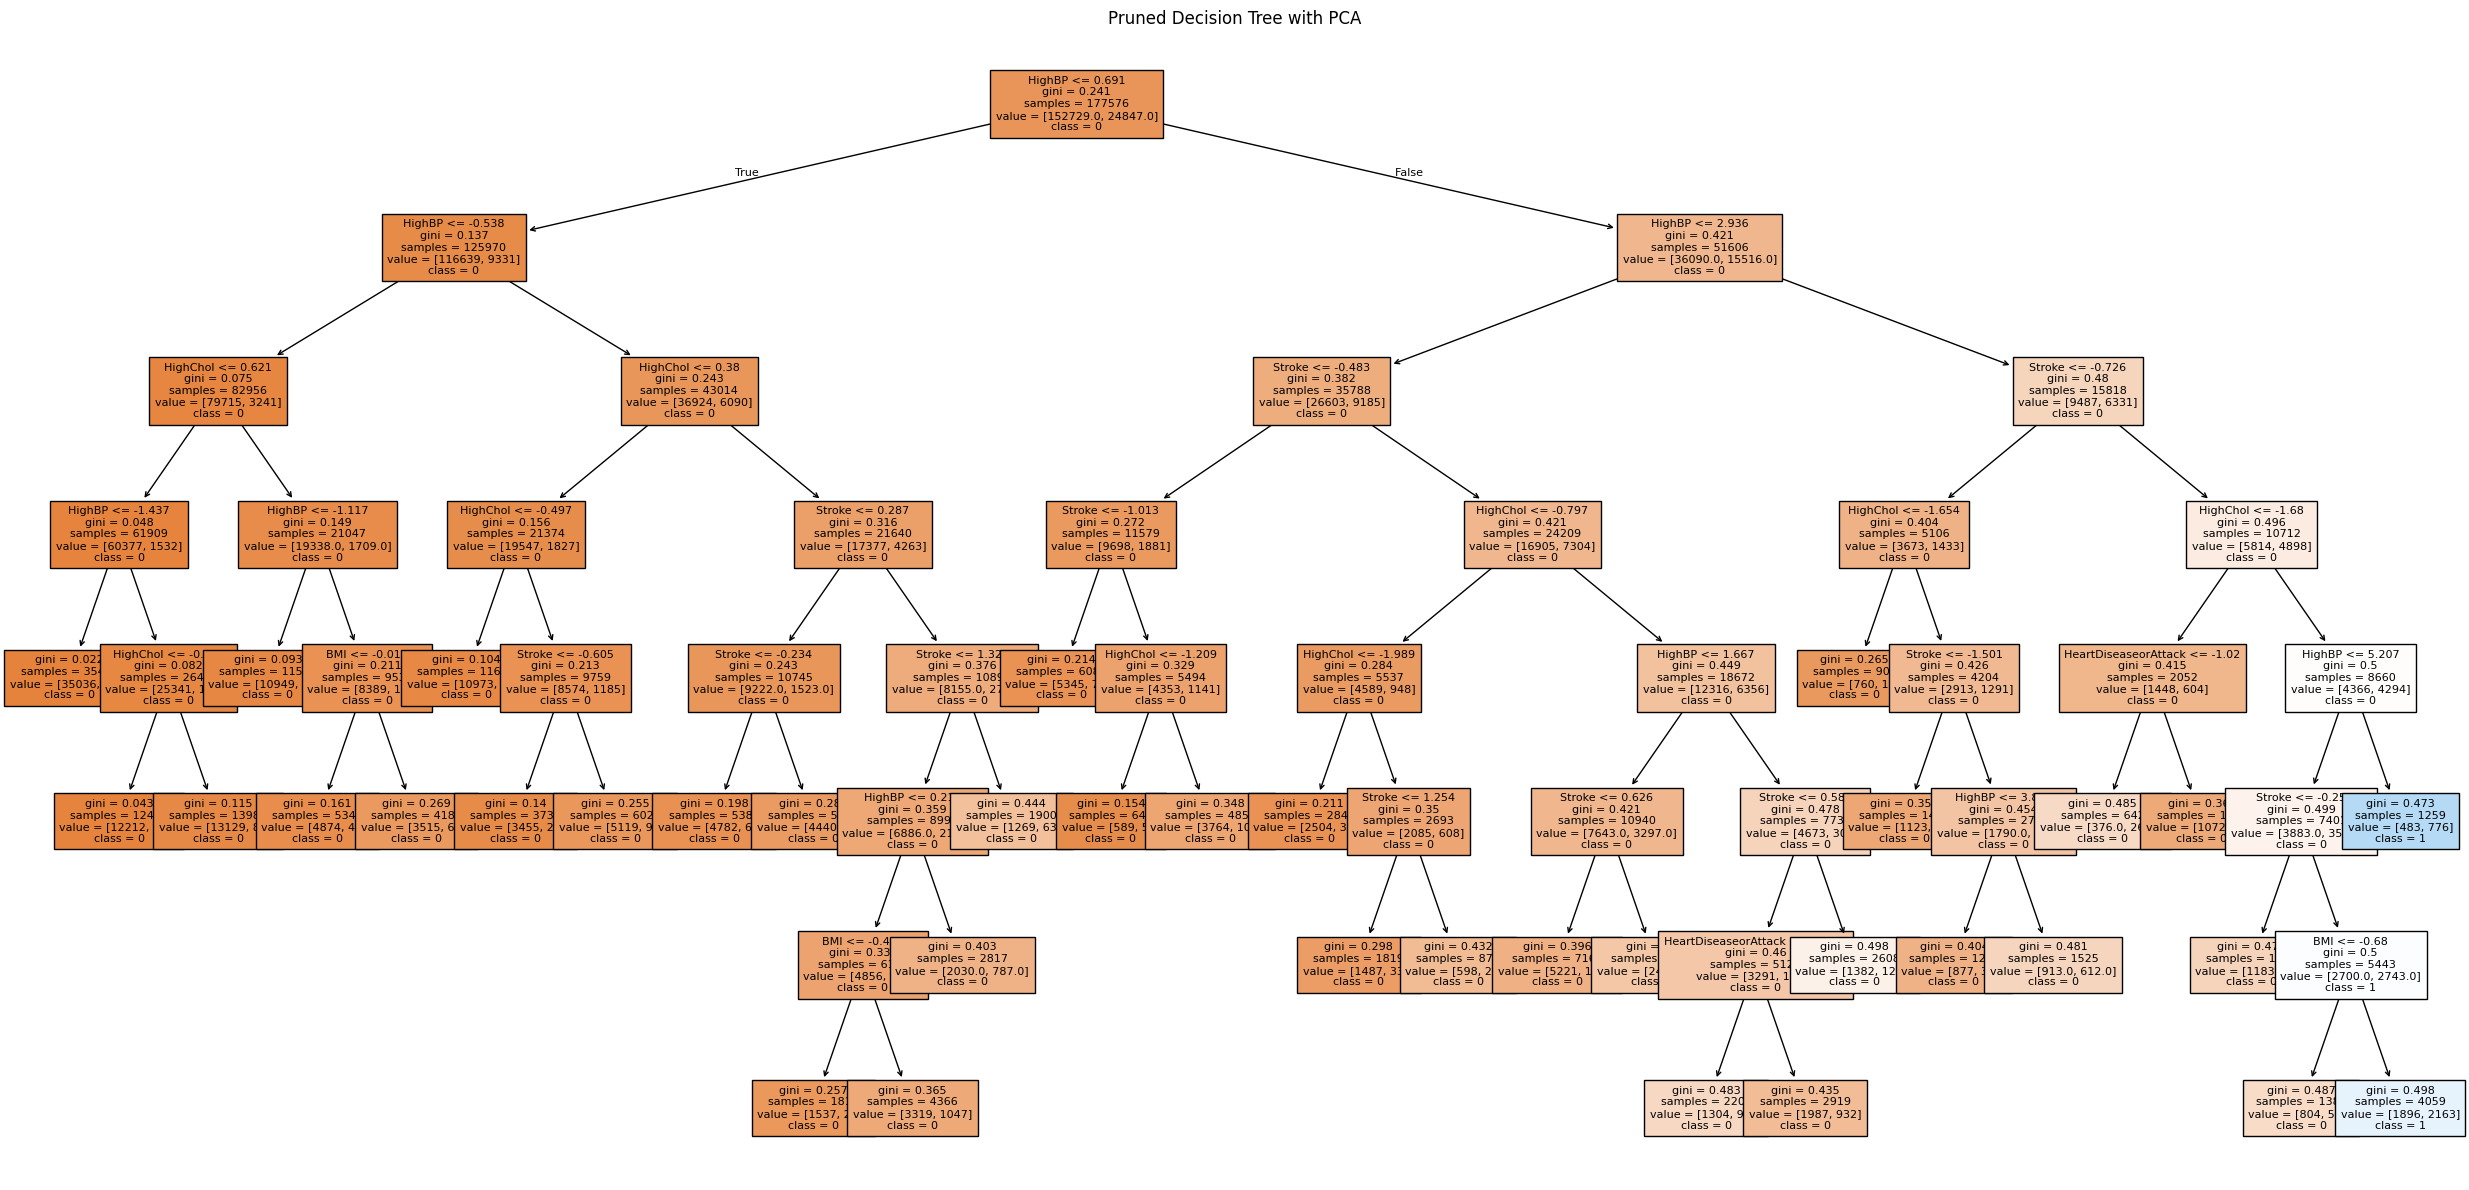

In [54]:
dt_pca_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pca_pruned.fit(X_train_pca, y_train_pca)

y_pred_pruned = dt_pca_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_pruned, y_test_pca, y_pred_pruned)
print_tree(dt_pca_pruned, dt_pca_pruned.get_depth(), "Pruned Decision Tree with PCA")

# Support Vector Machines

In [55]:
def show_metrics_svm(model, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Opzionale: Se il modello è un SVC (non LinearSVC), possiamo stampare i vettori di supporto
    if hasattr(model, 'n_support_'):
        print(f"Numero di vettori di supporto: {sum(model.n_support_)}")

    print("\n" + classification_report(y_test, y_pred))

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.title("Matrice di Confusione (SVM)")
    plt.show()

## Linear Kernel

Accuracy: 0.8620
Numero di vettori di supporto: 55437

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     65605
           1       0.00      0.00      0.00     10499

    accuracy                           0.86     76104
   macro avg       0.43      0.50      0.46     76104
weighted avg       0.74      0.86      0.80     76104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


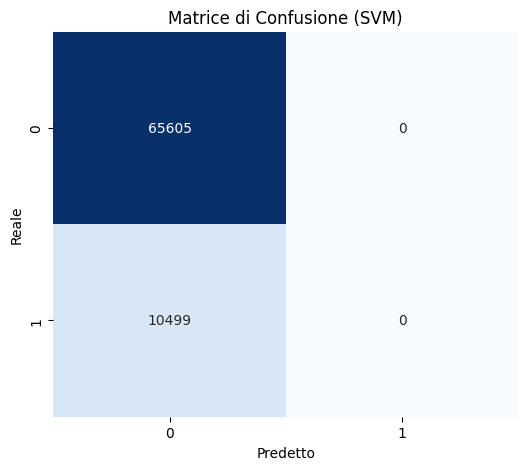

In [56]:
from sklearn.svm import LinearSVC, SVC

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

show_metrics_svm(svm_linear, y_test, y_pred_linear)


## Kernel RBF

Accuracy: 0.8648
Numero di vettori di supporto: 3566

              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.58      0.07      0.13     10499

    accuracy                           0.86     76104
   macro avg       0.73      0.53      0.53     76104
weighted avg       0.83      0.86      0.82     76104



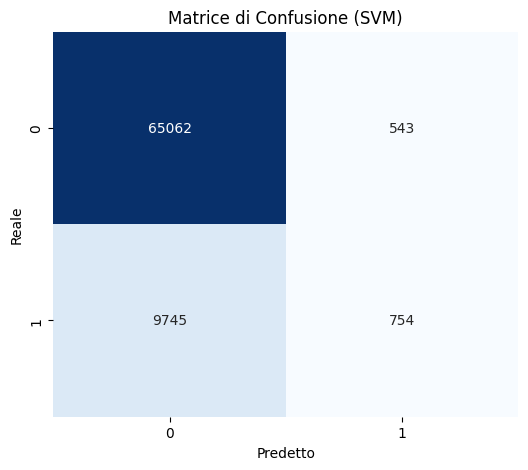

In [57]:
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_small, y_train_small)
y_pred_rbf = svm_rbf.predict(X_test)

show_metrics_svm(svm_rbf, y_test, y_pred_rbf)